# Edge localized mode
Use the **Python (FAITH labelmaker)** kernel. Change `shot` and `source` below.
Labels use 50 ms bins and 20 rho bins: gray = 0, white = unknown.


In [ ]:
from labeler.events.notebooks import load_shot, plot_shot

shot = 155151
source = "format/shots"
grid = load_shot("edge_localized_mode", shot, source=source)
grid["categories"]

### Original labels
Original annotations before class merging or 50 ms aggregation.

In [ ]:
import matplotlib.pyplot as plt
import yaml

from labeler.config import Paths
from labeler.events.source_formatters import read_elm

event, shot = grid["event"], grid["shot"]
root = Paths.from_env().label_tables
manifest = yaml.safe_load((root / "events.yaml").read_text())
spec = next(row for row in manifest["format_datasets"] if row["name"] == event)
raw = {row["stem"]: root / row["path"] for row in manifest["raw_datasets"]}
paths = {stem: raw[stem] for stem in spec["sources"]}
fig, ax = plt.subplots(figsize=(10, 3.5), layout="constrained")
trace = next((r for r in read_elm(*paths.values()) if r[0] == shot), None)
if trace is None:
    plt.close(fig)
    print(f"No original ELM labels for shot {shot}")
else:
    _, times, labels = trace
    ax.plot(times, labels, linewidth=0.8)
    ax.set(
        xlabel="Time (ms)",
        ylabel="Original binary label",
        yticks=[0, 1],
        ylim=(-0.05, 1.1),
        title=f"Shot {shot} — original 1 ms ELM onset labels",
    )
    plt.show()

### Formatted labels
The saved grid uses 50 ms bins, with each label broadcast over 20 rho bins.

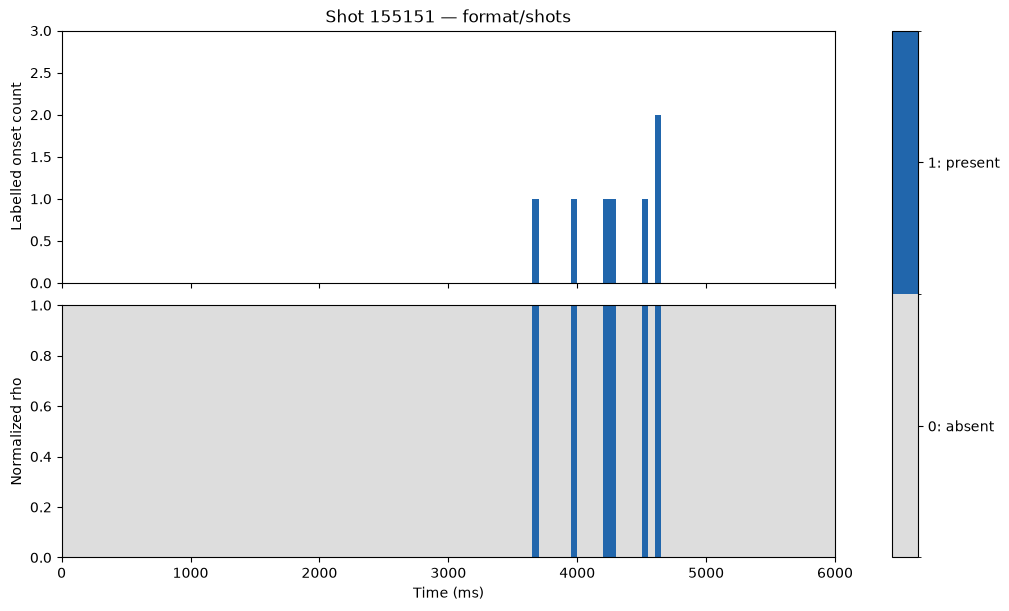

In [3]:
plot_shot(grid);

When extended labels are available, set `source` to `extend_<producer>/<shot-list>`.